# I. Observarea statistică

## Studiul tranzacțiilor cafenelelor din New York

Studiul utilizează setul de date `Coffee Shop Sales.csv` și examinează tranzacțiile înregistrate în trei locații de cafenea din New York, în perioada **1 ianuarie 2023 – 30 iunie 2023**.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:

date = pd.read_csv('Coffee Shop Sales.csv')
date['transaction_date'] = pd.to_datetime(date['transaction_date'], format='%m/%d/%y')
date.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,7:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,7:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,7:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,7:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,7:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


### 1.1. Scopul observării statistice

Scopul observării statistice este analiza structurii și dinamicii tranzacțiilor de vânzare efectuate în cele trei cafenele din New York, în perioada 1 ianuarie 2023 – 30 iunie 2023. Observarea urmărește volumul tranzacțiilor, cantitățile vândute, prețurile unitare, structura produselor și distribuția vânzărilor pe locații și în timp.

### 1.2. Populația statistică

Populația statistică este formată din totalitatea tranzacțiilor de vânzare înregistrate în fișier pentru cafenelele Astoria, Hell's Kitchen și Lower Manhattan. Unitatea statistică este o tranzacție individuală înregistrată. Codul `transaction_id` este utilizat pentru identificarea tranzacției.

### 1.3. Metoda de observare

S-a utilizat observarea indirectă, documentară, deoarece informațiile provin dintr-o bază de date existentă. Datele au caracter secundar. În cadrul universului definit de fișier, cercetarea este totală, deoarece sunt analizate toate înregistrările disponibile.

In [3]:
verificare_esantion = pd.Series({
    "Număr de înregistrări": len(date),
    "Tranzacții unice": date["transaction_id"].nunique(),
    "Prima zi observată": date["transaction_date"].min().date(),
    "Ultima zi observată": date["transaction_date"].max().date(),
    "Număr de zile observate": date["transaction_date"].nunique(),
    "Număr de locații": date["store_location"].nunique()
})

verificare_esantion

Număr de înregistrări          149116
Tranzacții unice               149116
Prima zi observată         2023-01-01
Ultima zi observată        2023-06-30
Număr de zile observate           181
Număr de locații                    3
dtype: object

### 1.4. Eșantionul observat

Eșantionul observat este alcătuit din 149.116 tranzacții unice, efectuate pe parcursul a 181 de zile, în cele trei locații Astoria, Hell's Kitchen și Lower Manhattan. Acesta reprezintă totalitatea înregistrărilor disponibile în fișier. Concluziile nu se generalizează automat la toate cafenelele din New York sau la alte perioade.

### 1.5. Caracteristicile statistice

| Grup | Caracteristici / variabile | Rol în analiză |
|---|---|---|
| Identificatori tehnici | `transaction_id`, `store_id`, `product_id` | Identifică tranzacția, locația și produsul |
| Temporale | `transaction_date`, `transaction_time` | Data și ora tranzacției |
| Cantitative | `transaction_qty`, `unit_price` | Cantitatea cumpărată și prețul unitar |
| Calitative | `store_location`, `product_category`, `product_type`, `product_detail` | Locația și clasificarea produsului |

Identificatorii tehnici permit evidența observațiilor, dar nu sunt utilizați ca variabile analitice.

### 1.6. Scalele de măsurare

| Caracteristica statistică | Tip | Scala de măsurare |
|---|---|---|
| `store_location`, `product_category`, `product_type`, `product_detail` | Calitativă | Nominală |
| `transaction_date`, `transaction_time` | Temporală | De interval |
| `transaction_qty` | Cantitativă discretă | De raport |
| `unit_price` | Cantitativă continuă | De raport |

Variabilele `transaction_id`, `store_id` și `product_id` sunt coduri de evidență nominale. Setul de date nu conține o caracteristică ordinală explicită.

In [4]:
locatii = (
    date[["store_id", "store_location"]]
    .drop_duplicates()
    .sort_values("store_id")
)

structura_date = pd.Series({
    "Număr de variabile": date.shape[1],
    "Număr de produse": date["product_id"].nunique(),
    "Număr de categorii": date["product_category"].nunique(),
    "Valori lipsă": int(date.isna().sum().sum())
})

display(locatii)
display(structura_date)

,store_id,store_location
105,3,Astoria
0,5,Lower Manhattan
17,8,Hell's Kitchen


Număr de variabile    11
Număr de produse      80
Număr de categorii     9
Valori lipsă           0
dtype: int64

### 1.7. Sursa de date

Sursa de date este fișierul local `Coffee Shop Sales.csv`, pus la dispoziție pentru această lucrare. Datele sunt secundare, deoarece provin dintr-o bază de date existentă din sursa web **https://www.kaggle.com**. Fișierul conține 11 variabile și nu prezintă valori lipsă. Autorul, metoda inițială de colectare și licența setului nu sunt precizate, astfel încât rezultatele sunt interpretate numai în limitele informațiilor disponibile.

# II. Sistematizarea şi prezentarea datelor observate

### 2.1. Tabelul descriptiv

Tabelul descriptiv prezintă primele 10 observații din setul de date. Setul complet, format din 149.116 tranzacții, este păstrat în fișierul `Coffee Shop Sales.csv`. Sunt afișate dimensiunea setului, tipurile de date și valorile lipsă.

In [5]:
rezumat_date = pd.DataFrame({
    "Indicator": ["Număr de observații", "Număr de variabile", "Valori lipsă"],
    "Valoare": [len(date), date.shape[1], int(date.isna().sum().sum())]
})

display(date.head(10))
display(rezumat_date)
display(date.dtypes.rename("Tip de date").to_frame())

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,7:06:11,2,5,Lower Manhattan,32,3.00,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,7:08:56,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,7:14:04,2,5,Lower Manhattan,59,4.50,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,7:20:24,1,5,Lower Manhattan,22,2.00,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,7:22:41,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
5,6,2023-01-01,7:22:41,1,5,Lower Manhattan,77,3.00,Bakery,Scone,Oatmeal Scone
6,7,2023-01-01,7:25:49,1,5,Lower Manhattan,22,2.00,Coffee,Drip coffee,Our Old Time Diner Blend Sm
7,8,2023-01-01,7:33:34,2,5,Lower Manhattan,28,2.00,Coffee,Gourmet brewed coffee,Columbian Medium Roast Sm
8,9,2023-01-01,7:39:13,1,5,Lower Manhattan,39,4.25,Coffee,Barista Espresso,Latte Rg
9,10,2023-01-01,7:39:34,2,5,Lower Manhattan,58,3.50,Drinking Chocolate,Hot chocolate,Dark chocolate Rg


,Indicator,Valoare
0,Număr de observații,149116
1,Număr de variabile,11
2,Valori lipsă,0


,Tip de date
transaction_id,int64
transaction_date,datetime64[us]
transaction_time,str
transaction_qty,int64
store_id,int64
store_location,str
product_id,int64
unit_price,float64
product_category,str
product_type,str


### 2.2. Clasificarea unităților statistice observate și calcularea ponderii în grupe

Tranzacțiile sunt clasificate după locația cafenelei, categoria produsului și tipul produsului. Pentru fiecare grupă se calculează frecvența absolută și ponderea în totalul de 149.116 tranzacții.

In [6]:
def tabel_frecvente(serie, denumire):
    rezultat = (
        serie.value_counts(dropna=False)
        .rename_axis(denumire)
        .reset_index(name="Frecvență")
    )
    rezultat["Pondere (%)"] = rezultat["Frecvență"] / len(serie) * 100

    total = pd.DataFrame({
        denumire: ["Total"],
        "Frecvență": [rezultat["Frecvență"].sum()],
        "Pondere (%)": [100.0]
    })

    return pd.concat([rezultat, total], ignore_index=True)

tabel_locatii = tabel_frecvente(date["store_location"], "Locație")
tabel_categorii = tabel_frecvente(date["product_category"], "Categorie produs")
tabel_tipuri = tabel_frecvente(date["product_type"], "Tip produs")

display(tabel_locatii)
display(tabel_categorii)
display(tabel_tipuri)

,Locație,Frecvență,Pondere (%)
0,Hell's Kitchen,50735,34.023847
1,Astoria,50599,33.932643
2,Lower Manhattan,47782,32.043510
3,Total,149116,100.000000


,Categorie produs,Frecvență,Pondere (%)
0,Coffee,58416,39.174871
1,Tea,45449,30.478956
2,Bakery,22796,15.287427
3,Drinking Chocolate,11468,7.690657
4,Flavours,6790,4.553502
5,Coffee beans,1753,1.175595
6,Loose Tea,1210,0.811449
7,Branded,747,0.500952
8,Packaged Chocolate,487,0.326591
9,Total,149116,100.000000


,Tip produs,Frecvență,Pondere (%)
0,Brewed Chai tea,17183,11.523244
1,Gourmet brewed coffee,16912,11.341506
2,Barista Espresso,16403,11.000161
3,Hot chocolate,11468,7.690657
4,Brewed Black tea,11350,7.611524
5,Brewed herbal tea,11245,7.541109
6,Scone,10173,6.822206
7,Organic brewed coffee,8489,5.692883
8,Drip coffee,8477,5.684836
9,Premium brewed coffee,8135,5.455484


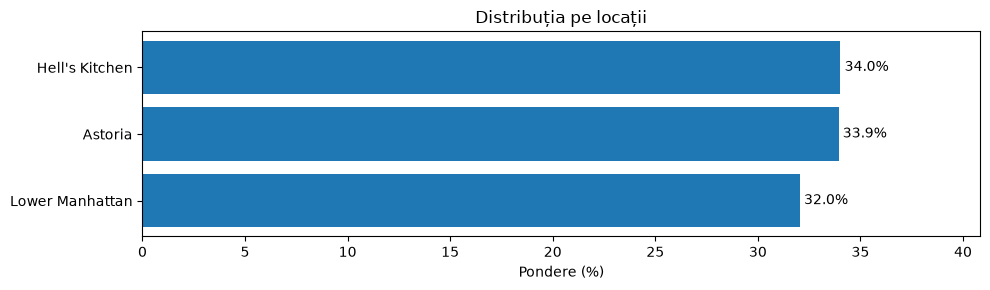

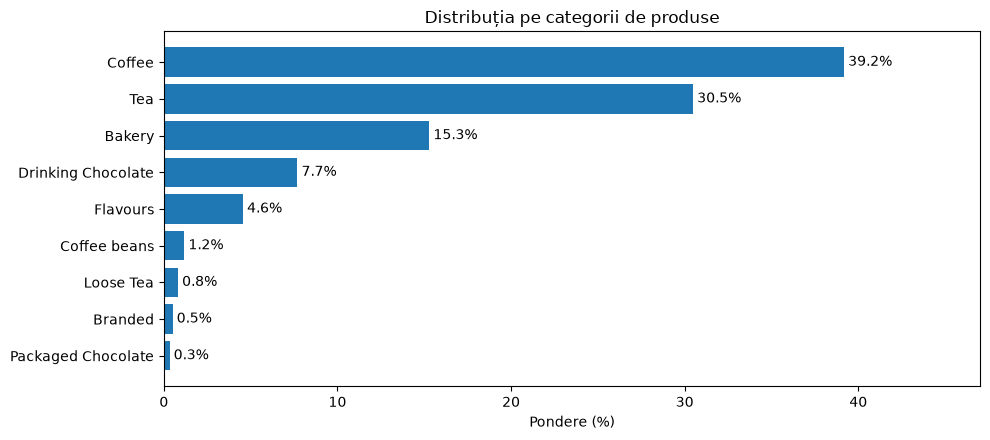

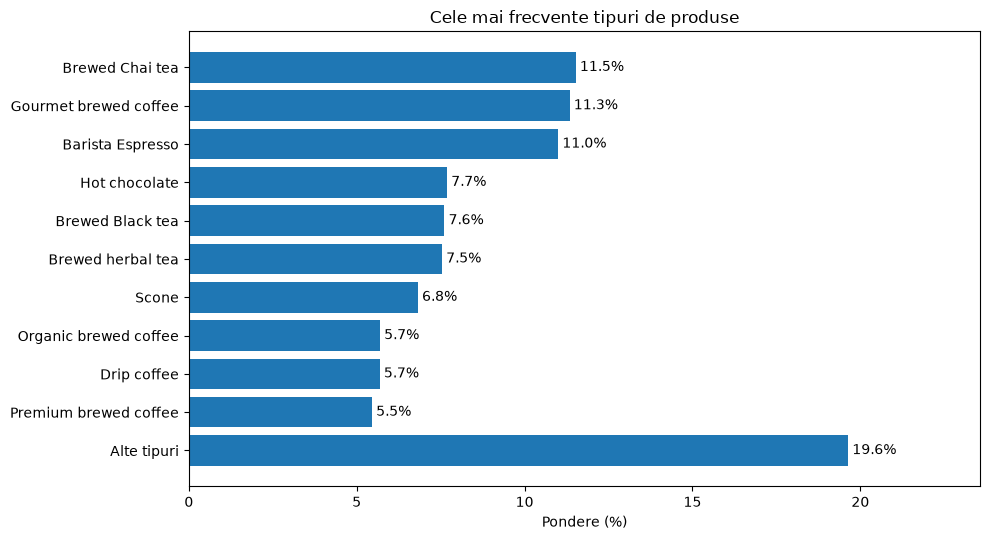

In [7]:
def diagrama_frecvente(tabel, coloana, titlu, top_n=None):
    valori = tabel.loc[
        tabel[coloana] != "Total",
        [coloana, "Pondere (%)"]
    ].sort_values("Pondere (%)", ascending=False).copy()

    if top_n is not None and len(valori) > top_n:
        pondere_alte = valori.iloc[top_n:]["Pondere (%)"].sum()
        valori = pd.concat([
            valori.iloc[:top_n],
            pd.DataFrame({
                coloana: ["Alte tipuri"],
                "Pondere (%)": [pondere_alte]
            })
        ], ignore_index=True)

    valori = valori.iloc[::-1]

    fig, ax = plt.subplots(figsize=(10, max(3, len(valori) * 0.5)))
    bare = ax.barh(valori[coloana].astype(str), valori["Pondere (%)"])
    ax.bar_label(bare, fmt="%.1f%%", padding=3)
    ax.set_xlim(0, valori["Pondere (%)"].max() * 1.2)
    ax.set_xlabel("Pondere (%)")
    ax.set_title(titlu)
    plt.tight_layout()
    plt.show()

diagrama_frecvente(tabel_locatii, "Locație", "Distribuția pe locații")
diagrama_frecvente(tabel_categorii, "Categorie produs", "Distribuția pe categorii de produse")
diagrama_frecvente(tabel_tipuri, "Tip produs", "Cele mai frecvente tipuri de produse", top_n=10)

### 2.3. Gruparea unităților statistice după o caracteristică cantitativă, utilizând intervale discrete și continue

Pentru caracteristica discretă `transaction_qty`, tranzacțiile sunt grupate după fiecare valoare posibilă a cantității cumpărate. Pentru caracteristica continuă `unit_price`, numărul de grupe este determinat prin formula lui Sturges:

`k = ceil(1 + 3,322 × lg(n))`

Lățimea intervalului se calculează astfel:

`h = (x_max − x_min) / k`

In [8]:
cantitati = pd.Series(
    range(date["transaction_qty"].min(), date["transaction_qty"].max() + 1)
)

grupare_cantitate = (
    date["transaction_qty"]
    .value_counts()
    .reindex(cantitati, fill_value=0)
    .rename_axis("Cantitate cumpărată")
    .reset_index(name="Frecvență")
)

grupare_cantitate["Pondere (%)"] = (
    grupare_cantitate["Frecvență"] / len(date) * 100
)

grupare_cantitate = pd.concat([
    grupare_cantitate,
    pd.DataFrame({
        "Cantitate cumpărată": ["Total"],
        "Frecvență": [len(date)],
        "Pondere (%)": [100.0]
    })
], ignore_index=True)

# Grupare continuă: prețul unitar
n = len(date)
x_min = date["unit_price"].min()
x_max = date["unit_price"].max()
amplitudine = x_max - x_min
k = int(np.ceil(1 + 3.322 * np.log10(n)))
h = amplitudine / k

limite = x_min + np.arange(k + 1) * h
limite[-1] = x_max

intervale_pret = pd.cut(
    date["unit_price"],
    bins=limite,
    include_lowest=True
)

grupare_pret = pd.DataFrame({
    "Interval preț unitar (USD)": [
        f"{interval.left:.2f}–{interval.right:.2f}"
        for interval in intervale_pret.cat.categories
    ],
    "Frecvență": intervale_pret.value_counts(sort=False).to_numpy()
})

grupare_pret["Pondere (%)"] = grupare_pret["Frecvență"] / n * 100

grupare_pret = pd.concat([
    grupare_pret,
    pd.DataFrame({
        "Interval preț unitar (USD)": ["Total"],
        "Frecvență": [n],
        "Pondere (%)": [100.0]
    })
], ignore_index=True)

parametri_grupare = pd.Series({
    "x_min (USD)": x_min,
    "x_max (USD)": x_max,
    "Amplitudinea A": amplitudine,
    "Număr de grupe k (Sturges)": k,
    "Lățimea intervalului h": h
})

display(parametri_grupare)
display(grupare_cantitate)
display(grupare_pret)

x_min (USD)                    0.800000
x_max (USD)                   45.000000
Amplitudinea A                44.200000
Număr de grupe k (Sturges)    19.000000
Lățimea intervalului h         2.326316
dtype: float64

,Cantitate cumpărată,Frecvență,Pondere (%)
0,1,87159,58.450468
1,2,58642,39.326430
2,3,3279,2.198959
3,4,23,0.015424
4,5,0,0.000000
5,6,3,0.002012
6,7,0,0.000000
7,8,10,0.006706
8,Total,149116,100.000000


,Interval preț unitar (USD),Frecvență,Pondere (%)
0,0.80–3.13,90047,60.387215
1,3.13–5.45,54857,36.788138
2,5.45–7.78,354,0.237399
3,7.78–10.11,1222,0.819496
4,10.11–12.43,346,0.232034
5,12.43–14.76,610,0.409077
6,14.76–17.08,148,0.099252
7,17.08–19.41,392,0.262883
8,19.41–21.74,514,0.344698
9,21.74–24.06,203,0.136136


### 2.4. Prezentarea grafică a distribuției unităților observate pe intervale de grupare și a structurii acestora

Graficele prezintă distribuția tranzacțiilor după cantitatea cumpărată și după intervalele de preț unitar. Pentru cantitate este utilizată și o diagramă circulară a structurii procentuale. Pentru preț, structura este redată prin bare procentuale.

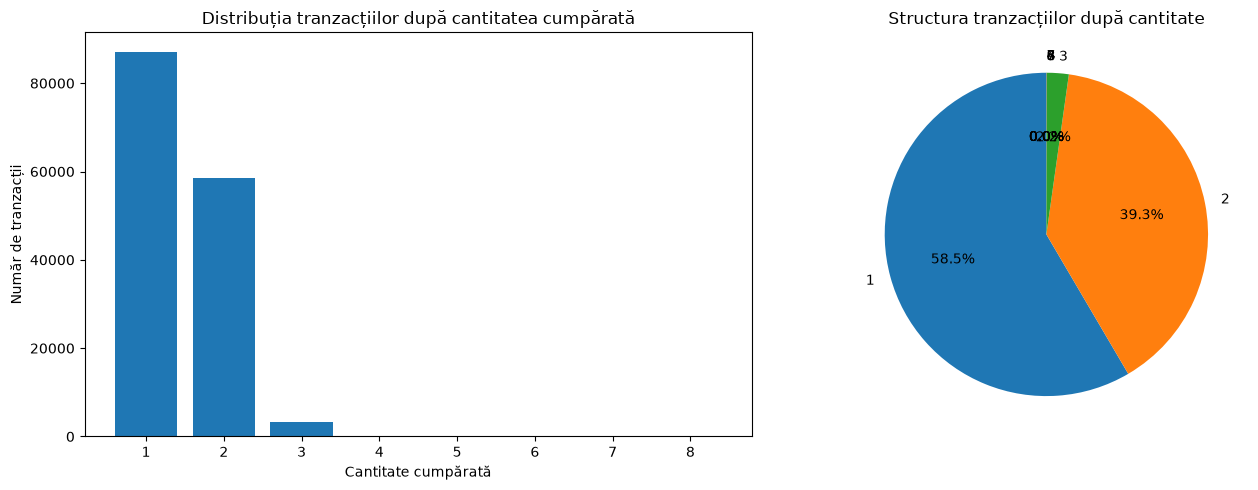

In [9]:
date_cantitate = grupare_cantitate.iloc[:-1].copy()

fig, axe = plt.subplots(1, 2, figsize=(14, 5))

axe[0].bar(
    date_cantitate["Cantitate cumpărată"].astype(str),
    date_cantitate["Frecvență"]
)
axe[0].set_title("Distribuția tranzacțiilor după cantitatea cumpărată")
axe[0].set_xlabel("Cantitate cumpărată")
axe[0].set_ylabel("Număr de tranzacții")

axe[1].pie(
    date_cantitate["Frecvență"],
    labels=date_cantitate["Cantitate cumpărată"].astype(str),
    autopct="%1.1f%%",
    startangle=90
)
axe[1].set_title("Structura tranzacțiilor după cantitate")

plt.tight_layout()
plt.show()

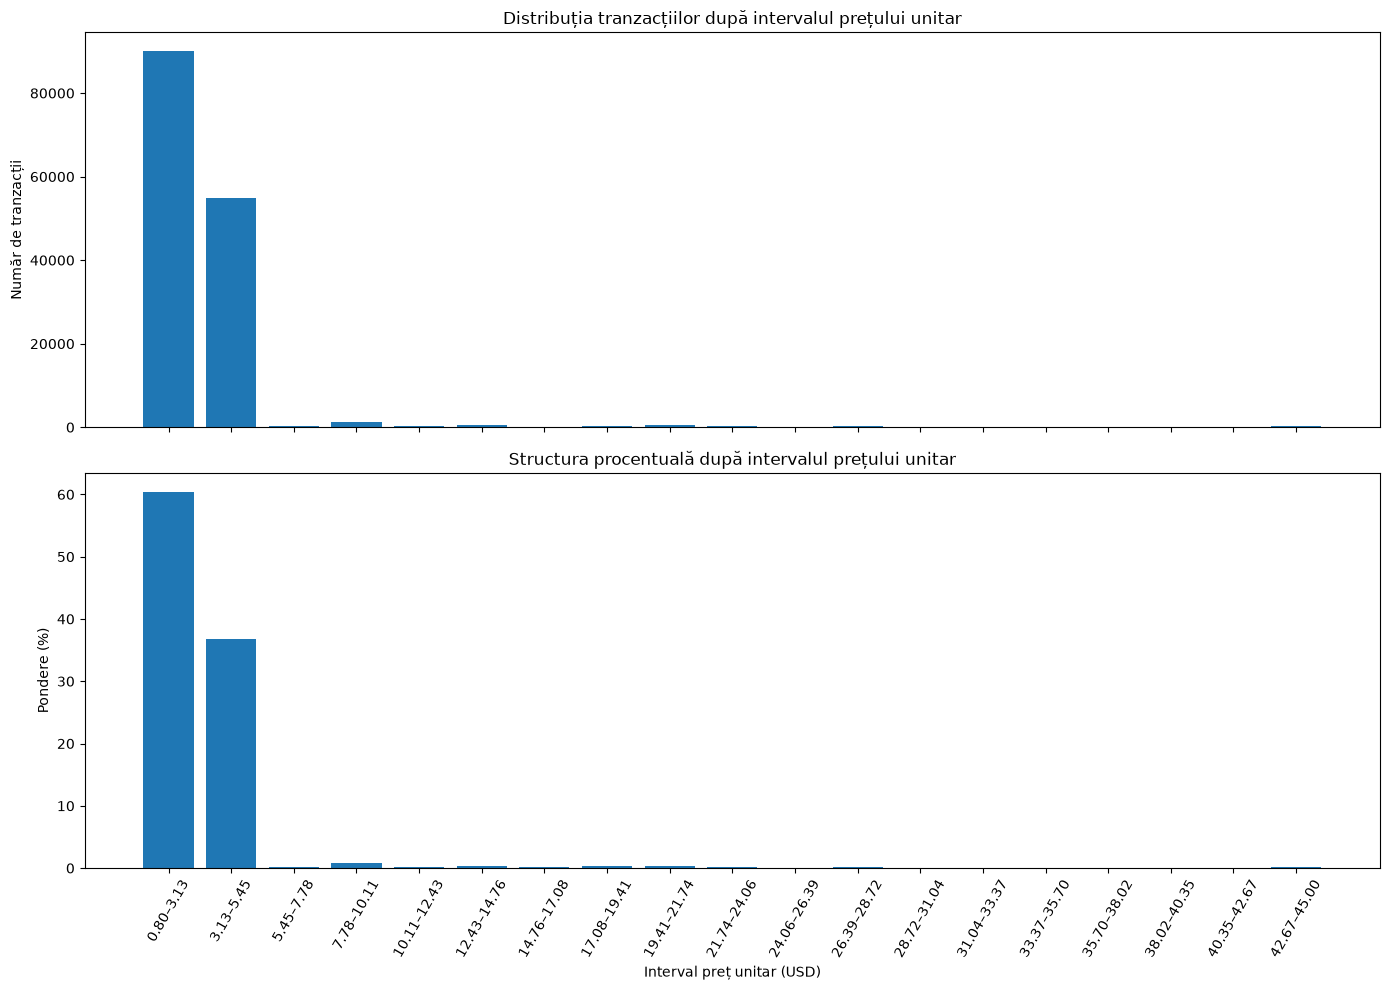

In [10]:
date_pret = grupare_pret.iloc[:-1].copy()

fig, axe = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

axe[0].bar(
    date_pret["Interval preț unitar (USD)"],
    date_pret["Frecvență"]
)
axe[0].set_title("Distribuția tranzacțiilor după intervalul prețului unitar")
axe[0].set_ylabel("Număr de tranzacții")

axe[1].bar(
    date_pret["Interval preț unitar (USD)"],
    date_pret["Pondere (%)"]
)
axe[1].set_title("Structura procentuală după intervalul prețului unitar")
axe[1].set_xlabel("Interval preț unitar (USD)")
axe[1].set_ylabel("Pondere (%)")

for ax in axe:
    ax.tick_params(axis="x", rotation=60)

plt.tight_layout()
plt.show()